In [5]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
from google.colab import files

uploaded = files.upload()
import pandas as pd

df = pd.read_csv("AmesHousing.csv")

Saving AmesHousing.csv to AmesHousing (1).csv


In [10]:
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


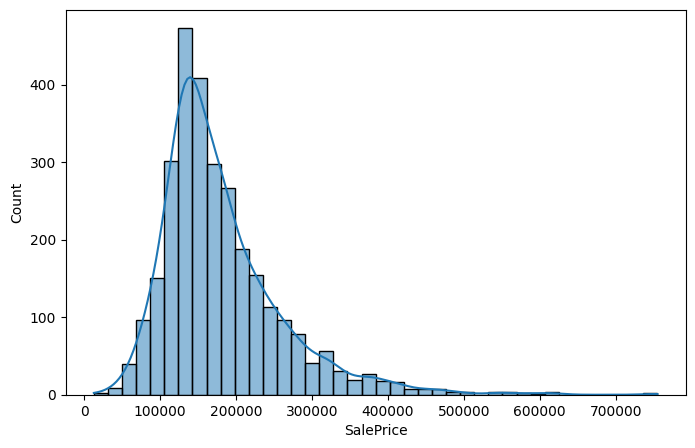

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], bins=40, kde=True)
plt.show()


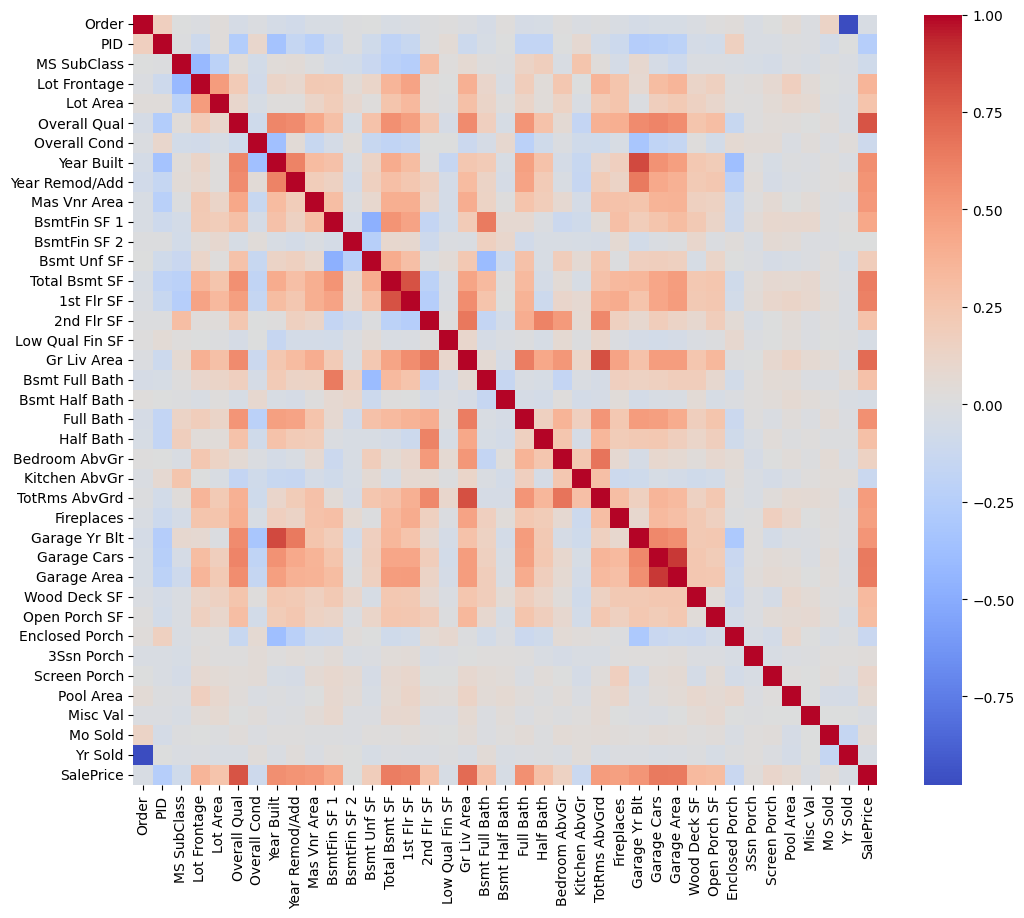

In [12]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm")

plt.show()

In [13]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

In [14]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

In [15]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
sgd_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(
        random_state=42,
        max_iter=2000,
        tol=1e-3
    ))
])

sgd_pipeline.fit(X_train, y_train)
train_pred = sgd_pipeline.predict(X_train)

test_pred = sgd_pipeline.predict(X_test)

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_train, X_test, y_train, y_test):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    return {
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

In [46]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(
        max_iter=5000,
        eta0=0.01,
        learning_rate="adaptive",
        random_state=42
    ))
])

In [47]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha":[0.01,0.1,1,10,50,100]
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_search.fit(X_train,y_train)

print(ridge_search.best_params_)

{'model__alpha': 10}


In [48]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

lasso_params = {
    "model__alpha":[0.001,0.01,0.1,1,10]
}

lasso_search = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_search.fit(X_train,y_train)

print(lasso_search.best_params_)

{'model__alpha': 10}


In [49]:
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline

# ElasticNet with Cross Validation
elastic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNetCV(
        l1_ratio=[0.2, 0.5, 0.8, 1.0],
        alphas=[0.1, 1, 10],
        cv=5,
        max_iter=10000,
        random_state=42
    ))
])

# Train
elastic_pipeline.fit(X_train, y_train)

# Best parameters
print("Best Alpha:", elastic_pipeline.named_steps["model"].alpha_)
print("Best l1_ratio:", elastic_pipeline.named_steps["model"].l1_ratio_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 283618436910.68066, tolerance: 1081630771.4729667
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3781596358.539551, tolerance: 1103990068.1049752
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 236196244013.53232, tolerance: 1103990068.1049752
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Con

Best Alpha: 0.1
Best l1_ratio: 0.8


In [50]:
# Make sure all models are fitted first
linear_pipeline.fit(X_train, y_train)
ridge_model = ridge_search.best_estimator_
ridge_model.fit(X_train, y_train)
lasso_pipeline.fit(X_train, y_train)
elastic_pipeline.fit(X_train, y_train)

results = []

results.append({
    "Model": "Linear (SGD)",
    **evaluate(linear_pipeline, X_train, X_test, y_train, y_test)
})

results.append({
    "Model": "Ridge",
    **evaluate(ridge_model, X_train, X_test, y_train, y_test)
})

results.append({
    "Model": "Lasso",
    **evaluate(lasso_pipeline, X_train, X_test, y_train, y_test)
})

results.append({
    "Model": "ElasticNet",
    **evaluate(elastic_pipeline, X_train, X_test, y_train, y_test)
})

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 283618436910.68066, tolerance: 1081630771.4729667
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3781596358.539551, tolerance: 1103990068.1049752
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 236196244013.53232, tolerance: 1103990068.1049752
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Con

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear (SGD),2.983175e+06,3.216390e+06,1.811807e+13,1.808071e+13,4.256533e+06,4.252142e+06,-3046.2360,-2254.1424
1,Ridge,1.443549e+04,1.657918e+04,5.267493e+08,8.503541e+08,2.295102e+04,2.916083e+04,0.9114,0.8939
2,Lasso,1.315996e+04,1.582196e+04,3.604218e+08,8.487260e+08,1.898478e+04,2.913290e+04,0.9394,0.8941
3,ElasticNet,1.492604e+04,1.645741e+04,6.029250e+08,8.658155e+08,2.455453e+04,2.942474e+04,0.8986,0.8920


Conclusion: Based on the evaluation metrics, Lasso Regression performed the best on the Ames Housing dataset. It achieved the highest test R² score and the lowest MAE, MSE, and RMSE among all the models, indicating better prediction accuracy on unseen data. Ridge and Elastic Net also gave competitive results, while the SGD-based linear regression performed poorly compared to the regularized models. Hence, Lasso Regression was the most effective model for this dataset.